# Systematic Model Comparison for Source-Sink Score Prediction

**Objective:** Compare different graph neural network architectures to identify the best model for predicting source-sink scores in phylogenetic networks.

**Structure:**
1. **Data Loading** - Load and preprocess phylogenetic graph data
2. **Model Definitions** - Define 5 models: SimpleMLP, SimpleAggregation, GraphSAGE, GAT, Edge-Informed GAT
3. **Training & Evaluation** - Unified functions for model training and evaluation
4. **Model Testing** - Systematically test each model
5. **Comparison & Diagnosis** - Final results and insights

## 1. Data Loading

Load phylogenetic graph data and convert to DGL format. Each graph represents a transmission network with:
- **Node features**: Initial_Population, Accumulated_Infections, Num_Samples (3D)
- **Node labels**: Source_Sink_Score (target variable)
- **Edge features**: Phylogenetic distance sequences (variable length, padded)

In [1]:
import pandas as pd
import os
from glob import glob
import numpy as np
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import dgl.function as fn
from dgl.nn.pytorch import GATConv, SAGEConv


def parse_edge_feature(edge_feature_str):
    """
    Parse edge feature string into float vector.
    
    Args:
        edge_feature_str: String representation of edge features (tab-separated values)
    
    Returns:
        List of floats representing phylogenetic distances
    """
    vector_str = str(edge_feature_str).strip('[]')
    return [float(v) for v in vector_str.split('\t')]


def load_data(input_folder, num_of_nodes, min_length, max_length):
    """
    Load phylogenetic graph data and convert to DGL format.
    
    Args:
        input_folder: Path to folder containing node and edge CSV files
        num_of_nodes: Expected number of nodes per graph
        min_length: Minimum edge feature length (inclusive)
        max_length: Maximum edge feature length (inclusive)
    
    Returns:
        dgl_graphs: List of DGL graphs
        edge_dim: Actual maximum edge feature dimension after padding
    """
    # Load all node and edge files
    node_files = glob(os.path.join(input_folder, "*_node.csv"))
    edge_files = glob(os.path.join(input_folder, "*_edge.csv"))
    print(f"Found {len(node_files)} node files and {len(edge_files)} edge files")

    all_nodes = pd.concat([pd.read_csv(f) for f in node_files], ignore_index=True)
    all_edges = pd.concat([pd.read_csv(f) for f in edge_files], ignore_index=True)

    # Filter fully connected graphs
    # Expected edges: n self-loops + n*(n-1)/2 undirected edges
    expected_edges = num_of_nodes + num_of_nodes * (num_of_nodes - 1) // 2
    node_counts = all_nodes.groupby('graph_id').size()
    edge_counts = all_edges.groupby('graph_id').size()

    fully_connected_ids = {
        gid for gid in node_counts.index
        if node_counts[gid] == num_of_nodes and edge_counts.get(gid, 0) == expected_edges
    }

    # Filter by edge feature length
    valid_graphs = {}
    actual_max_length = 0

    for graph_id in fully_connected_ids:
        graph_edges = all_edges[all_edges['graph_id'] == graph_id]
        edge_vectors = [parse_edge_feature(ef) for ef in graph_edges['edge_features']]
        lengths = [len(v) for v in edge_vectors]
        min_len, max_len = min(lengths), max(lengths)

        # Only include graphs with edge features in specified length range
        if min_len >= min_length and max_len <= max_length:
            valid_graphs[graph_id] = edge_vectors
            actual_max_length = max(actual_max_length, max_len)

    print(f"Valid graphs: {len(valid_graphs)}")

    # Convert to DGL graphs
    dgl_graphs = []
    for graph_id in valid_graphs.keys():
        node_df = all_nodes[all_nodes['graph_id'] == graph_id].sort_values('node').reset_index(drop=True)
        edge_df = all_edges[all_edges['graph_id'] == graph_id]

        # Extract node features and labels
        node_features = node_df[['Initial_Population', 'Accumulated_Infections', 'Num_Samples']].values.astype(np.float32)
        node_labels = node_df['Source_Sink_Score'].values.astype(np.float32)

        # Extract edge indices
        src_nodes = edge_df['node1'].values.astype(np.int64)
        dst_nodes = edge_df['node2'].values.astype(np.int64)

        # Pad edge features with zeros to uniform length
        padded_edge_features = [
            vec + [0.0] * (actual_max_length - len(vec))
            for vec in valid_graphs[graph_id]
        ]

        # Create DGL graph
        g = dgl.graph((torch.tensor(src_nodes), torch.tensor(dst_nodes)))
        g.ndata['feat'] = torch.tensor(node_features, dtype=torch.float32)
        g.ndata['label'] = torch.tensor(node_labels, dtype=torch.float32)
        g.edata['feat'] = torch.tensor(padded_edge_features, dtype=torch.float32)
        
        # Convert to bidirected graph (add reverse edges)
        g = dgl.to_bidirected(g, copy_ndata=True)
        
        # Fix edge features after bidirectionalization
        if 'feat' not in g.edata or g.edata['feat'].shape[0] != g.num_edges():
            edge_to_feat = {(s, d): torch.tensor(padded_edge_features[i]) 
                           for i, (s, d) in enumerate(zip(src_nodes, dst_nodes))}
            new_edge_feats = []
            for s, d in zip(*g.edges()):
                s, d = s.item(), d.item()
                # Get feature from either direction (undirected)
                feat = edge_to_feat.get((s, d), edge_to_feat.get((d, s)))
                new_edge_feats.append(feat)
            g.edata['feat'] = torch.stack(new_edge_feats)
        
        g.graph_id = graph_id
        dgl_graphs.append(g)

    print(f"Converted {len(dgl_graphs)} graphs to DGL format")
    return dgl_graphs, actual_max_length


# Load data
input_folder = '/Users/lukelyu/Desktop/epidata/100_10/'
dgl_graphs, edge_dim = load_data(input_folder, num_of_nodes=10, min_length=0, max_length=5000)

# Split data: 70% train, 15% validation, 15% test
torch.manual_seed(42)
train_graphs, temp_graphs = train_test_split(dgl_graphs, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.5, random_state=42)

print(f"\nData split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")
print(f"Node feature dim: 3, Edge feature dim: {edge_dim}")

Found 100 node files and 100 edge files
Valid graphs: 621
Converted 621 graphs to DGL format

Data split: Train=434, Val=93, Test=94
Node feature dim: 3, Edge feature dim: 4977


## 2. Model Definitions

We compare 5 different architectures:
1. **SimpleMLP** - Baseline using only node features (ignores graph structure)
2. **SimpleAggregation** - Mean pooling of neighbor features without learned transformation
3. **GraphSAGE** - Standard GraphSAGE with mean aggregator
4. **StandardGAT** - DGL's Graph Attention Network
5. **EdgeInformedGAT** - Custom GAT with edge feature attention

In [2]:
# ==============================================================================
# MODEL 1: SimpleMLP (Baseline - No Graph Structure)
# ==============================================================================
class SimpleMLP(nn.Module):
    """
    Baseline MLP model that ignores graph structure and only uses node features.
    
    Architecture:
    -------------
    3 → 64 → 32 → 1
    
    Dimension Flow:
    ---------------
    Input:  node_feat (N, 3)         - N nodes, each with 3 features
    
    Layer 1: Linear(3 → 64)          → (N, 64)
    Layer 2: ReLU                    → (N, 64)
    Layer 3: Linear(64 → 32)         → (N, 32)
    Layer 4: ReLU                    → (N, 32)
    Layer 5: Linear(32 → 1)          → (N, 1)
    
    Output: squeeze(-1)              → (N,) - One prediction per node
    
    Key Feature:
    ------------
    Graph structure (edges) is completely ignored. Only node features are used.
    """
    def __init__(self, in_dim=3):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),      # (N, 3) → (N, 64)
            nn.ReLU(),
            nn.Linear(64, 32),          # (N, 64) → (N, 32)
            nn.ReLU(),
            nn.Linear(32, 1)            # (N, 32) → (N, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass.
        
        Args:
            g: DGL graph (not used)
            node_feat: (N, 3) - Node features
            edge_feat: Edge features (not used)
        
        Returns:
            (N,) - One scalar prediction per node
        """
        return self.net(node_feat).squeeze(-1)  # (N, 1) → (N,)


# ==============================================================================
# MODEL 2: SimpleAggregation (Mean Pooling Without Learned Transformation)
# ==============================================================================
class SimpleAggregation(nn.Module):
    """
    Simple graph model using mean aggregation without learned transformations.
    
    Architecture:
    -------------
    Message passing (mean) → Residual connection → MLP classifier
    
    Process:
    --------
    1. Aggregate neighbor features via mean pooling (no learned weights)
    2. Combine with self features using residual connection
    3. Pass through small MLP for classification
    
    Dimension Flow:
    ---------------
    Input:  node_feat (N, 3)                - Original node features
    
    Message Passing:
        Copy to neighbors                   → (N, 3) per node
        Mean aggregation                    → (N, 3) - Aggregated neighbors
    
    Residual Connection:
        self + aggregated                   → (N, 3) - Combined features
    
    Classifier MLP:
        Linear(3 → 8)                       → (N, 8)
        ReLU                                → (N, 8)
        Linear(8 → 1)                       → (N, 1)
    
    Output: squeeze(-1)                     → (N,)
    
    Key Feature:
    ------------
    Uses graph structure but NO learned feature transformation before aggregation.
    Simplest graph-aware baseline.
    """
    def __init__(self, in_dim=3):
        super(SimpleAggregation, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 8),       # (N, 3) → (N, 8)
            nn.ReLU(),
            nn.Linear(8, 1)             # (N, 8) → (N, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass.
        
        Args:
            g: DGL graph with edges
            node_feat: (N, 3) - Node features
            edge_feat: Edge features (not used)
        
        Returns:
            (N,) - One scalar prediction per node
        """
        with g.local_scope():
            g.ndata['h'] = node_feat                          # Store: (N, 3)
            
            # Message passing: copy features to neighbors and average
            g.update_all(fn.copy_u('h', 'm'),                 # Send: (N, 3)
                        fn.mean('m', 'h_agg'))                # Aggregate: (N, 3)
            
            # Residual connection: combine self + aggregated neighbors
            h_combined = node_feat + g.ndata['h_agg']         # (N, 3) + (N, 3) → (N, 3)
            
            return self.classifier(h_combined).squeeze(-1)    # (N, 3) → (N, 8) → (N, 1) → (N,)


# ==============================================================================
# MODEL 3: GraphSAGE (Standard GraphSAGE with Mean Aggregator)
# ==============================================================================
class GraphSAGE(nn.Module):
    """
    Standard GraphSAGE model with mean aggregation and learned transformation.
    
    Architecture:
    -------------
    SAGEConv (mean aggregator) → MLP classifier
    
    Process:
    --------
    GraphSAGE performs neighborhood aggregation with learned transformations:
    1. Aggregate neighbor features via MEAN pooling
    2. Concatenate self features with aggregated neighbor features
    3. Apply learned LINEAR transformation to combined features
    
    Dimension Flow:
    ---------------
    Input:  node_feat (N, 3)                - Original node features
    
    SAGEConv Layer (mean aggregator):
        Step 1: Aggregate neighbors         → (N, 3) - Mean of neighbor features
        Step 2: Concatenate [self || agg]   → (N, 6) - Self + aggregated
        Step 3: Linear transformation       → (N, 32) - Learned projection
    
    After SAGE: h (N, 32)
    
    Classifier MLP:
        Linear(32 → 8)                      → (N, 8)
        ReLU                                → (N, 8)
        Linear(8 → 1)                       → (N, 1)
    
    Output: squeeze(-1)                     → (N,)
    
    Key Feature:
    ------------
    Combines graph structure with LEARNED transformations. The key difference from
    SimpleAggregation is that GraphSAGE applies a learned linear layer AFTER
    concatenating self and neighbor features.
    """
    def __init__(self, in_dim=3, hidden_dim=32):
        super(GraphSAGE, self).__init__()
        # SAGEConv: (N, 3) → (N, 32) via learned aggregation
        self.conv = SAGEConv(in_dim, hidden_dim, aggregator_type='mean')
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 8),   # (N, 32) → (N, 8)
            nn.ReLU(),
            nn.Linear(8, 1)             # (N, 8) → (N, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass.
        
        Args:
            g: DGL graph with edges
            node_feat: (N, 3) - Node features
            edge_feat: Edge features (not used)
        
        Returns:
            (N,) - One scalar prediction per node
        """
        # GraphSAGE convolution with learned transformation
        h = self.conv(g, node_feat)                     # (N, 3) → (N, 32)
        
        # Classification head
        return self.classifier(h).squeeze(-1)           # (N, 32) → (N, 8) → (N, 1) → (N,)


# ==============================================================================
# MODEL 4: StandardGAT (Graph Attention Network)
# ==============================================================================
class StandardGAT(nn.Module):
    """
    Standard Graph Attention Network using multi-head attention mechanism.
    
    Architecture:
    -------------
    Multi-head GATConv → MLP classifier
    
    Process:
    --------
    GAT learns attention weights to weigh neighbor contributions differently:
    1. Each head transforms node features independently
    2. Compute attention scores from node features (NOT edges)
    3. Aggregate neighbors weighted by learned attention
    4. Concatenate outputs from all attention heads
    
    Dimension Flow:
    ---------------
    Input:  node_feat (N, 3)                - Original node features
    
    GATConv Layer (multi-head attention, num_heads=2):
        For each head h:
            Linear transformation           → (N, 32) per head
            Attention: α_ij = f(h_i, h_j)  → (E,) attention weights per edge
            Weighted aggregation            → (N, 32) per head
        
        Concatenate all heads               → (N, 32 × 2) = (N, 64)
    
    After GAT: h (N, 64)                    - Concatenated multi-head output
    
    Classifier MLP:
        Linear(64 → 8)                      → (N, 8)
        ReLU                                → (N, 8)
        Linear(8 → 1)                       → (N, 1)
    
    Output: squeeze(-1)                     → (N,)
    
    Key Feature:
    ------------
    Attention mechanism learns which neighbors are most important based on
    NODE FEATURES. Attention is computed from source and destination node
    features, NOT from edge features.
    """
    def __init__(self, in_dim=3, hidden_dim=32, num_heads=2):
        super(StandardGAT, self).__init__()
        # GATConv: (N, 3) → (N, num_heads × hidden_dim) = (N, 64)
        self.conv = GATConv(in_dim, hidden_dim, num_heads)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 8),  # (N, 64) → (N, 8)
            nn.ReLU(),
            nn.Linear(8, 1)                        # (N, 8) → (N, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass.
        
        Args:
            g: DGL graph with edges
            node_feat: (N, 3) - Node features
            edge_feat: Edge features (not used)
        
        Returns:
            (N,) - One scalar prediction per node
        """
        # GAT convolution with multi-head attention
        # Output shape: (N, num_heads, hidden_dim) = (N, 2, 32)
        h = self.conv(g, node_feat)                 # (N, 3) → (N, 2, 32)
        
        # Flatten/concatenate attention heads
        h = h.flatten(1)                            # (N, 2, 32) → (N, 64)
        
        # Classification head
        return self.classifier(h).squeeze(-1)       # (N, 64) → (N, 8) → (N, 1) → (N,)


# ==============================================================================
# MODEL 5: EdgeInformedGAT (Custom GAT with Edge-Based Attention)
# ==============================================================================
class SimpleEdgeEncoder(nn.Module):
    """
    Encode variable-length edge features into fixed-size representations.

    Converts phylogenetic distance sequences (variable length, zero-padded)
    into fixed 32D vectors using statistical summaries.

    Dimension Flow:
    ---------------
    Input:  edge_feat (E, max_len)          - E edges, each with max_len values (zero-padded)

    Step 1: Compute statistics (ignore padding zeros):
        - Mean of non-zero values           → (E, 1)
        - Max of all values                 → (E, 1)
        - Std of non-zero values            → (E, 1)
        - Normalized count (% non-zero)     → (E, 1)

    Step 2: Concatenate statistics          → (E, 4)
    Step 3: Linear(4 → 32)                  → (E, 32) - Encoded edge features

    Output: (E, 32) - Fixed-size edge encodings
    """
    def __init__(self, out_dim=32):
        super(SimpleEdgeEncoder, self).__init__()
        self.fc = nn.Linear(4, out_dim)  # (E, 4) → (E, 32)

    def forward(self, edge_feat):
        """
        Forward pass.
        
        Args:
            edge_feat: (E, max_len) - Padded edge features
        
        Returns:
            (E, 32) - Encoded edge features
        """
        # Create mask for non-zero values (zeros are padding)
        mask = (edge_feat != 0).float()                         # (E, max_len)
        count = mask.sum(dim=1, keepdim=True)                   # (E, 1)

        # Compute statistics only on non-zero values
        sum_vals = (edge_feat * mask).sum(dim=1, keepdim=True)  # (E, 1)
        mean = sum_vals / (count + 1e-8)                        # (E, 1)
        max_val, _ = edge_feat.max(dim=1, keepdim=True)         # (E, 1)

        # Standard deviation of non-zero values
        diff = (edge_feat - mean) * mask                        # (E, max_len)
        std = torch.sqrt((diff ** 2).sum(dim=1, keepdim=True) / (count + 1e-8))  # (E, 1)

        # Normalized count (percentage of non-zero values)
        normalized_count = count / edge_feat.shape[1]           # (E, 1)

        # Concatenate statistics and project to out_dim
        stats = torch.cat([mean, max_val, std, normalized_count], dim=1)  # (E, 4)
        return self.fc(stats)                                   # (E, 4) → (E, 32)


class EdgeInformedGATLayer(nn.Module):
    """
    Single-head GAT layer where ONLY edge features determine attention weights.

    Process:
    --------
    This layer computes attention-weighted message passing where:
    - Node features are transformed (each head has its own node encoder)
    - Edge features SOLELY determine attention scores (key difference!)
    - Message passing aggregates neighbor information weighted by edge attention

    Attention Formula:
    ------------------
    z_i = W_node * h_i                    (node transformation)
    e_ij = LeakyReLU(W_edge * edge_ij)    (attention from edges)
    α_ij = softmax_j(e_ij)                (normalize attention)
    h_i' = Σ_j α_ij * z_j                 (message passing)

    Dimension Flow:
    ---------------
    Input:
        - node_feat (N, in_dim)             - Node features
        - edge_feat (E, edge_dim)           - Encoded edge features

    Node Transformation:
        W_node: Linear(in_dim → out_dim)    → (N, out_dim) - z_i for each node

    Edge-Based Attention:
        W_edge: Linear(edge_dim → 1)        → (E, 1) - Raw attention scores e_ij
        LeakyReLU(e_ij)                     → (E, 1) - Activated scores
        softmax_j(e_ij)                     → (E, 1) - Normalized attention α_ij

    Message Passing:
        α_ij * z_j                          → (E, out_dim) - Weighted neighbor features
        Σ_j α_ij * z_j                      → (N, out_dim) - Aggregated features h_i'

    Output: (N, out_dim) - Updated node features
    """
    def __init__(self, in_dim, out_dim, edge_dim):
        """
        Initialize single-head attention layer.

        Args:
            in_dim: Input node feature dimension
            out_dim: Output node feature dimension (per head)
            edge_dim: Edge feature dimension (encoded)
        """
        super(EdgeInformedGATLayer, self).__init__()
        self.out_dim = out_dim

        # Node encoder - each head has its own transformation
        self.fc_node = nn.Linear(in_dim, out_dim, bias=False)

        # Edge to attention score transformation
        self.fc_edge = nn.Linear(edge_dim, 1, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize parameters with Xavier/Glorot initialization."""
        gain = nn.init.calculate_gain('relu')
        nn.init.xavier_normal_(self.fc_node.weight, gain=gain)
        nn.init.xavier_normal_(self.fc_edge.weight, gain=gain)

    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass with edge-only attention.

        Args:
            g: DGL graph with E edges
            node_feat: (N, in_dim) - Node features
            edge_feat: (E, edge_dim) - Encoded edge features

        Returns:
            (N, out_dim) - Updated node features
        """
        with g.local_scope():
            # Node transformation (each head has own encoder)
            z = self.fc_node(node_feat)                 # (N, in_dim) → (N, out_dim)
            g.ndata['z'] = z

            # Compute attention scores from edge features ONLY
            e = self.fc_edge(edge_feat)                 # (E, edge_dim) → (E, 1)
            g.edata['e'] = F.leaky_relu(e)              # (E, 1)

            # Normalize attention weights using softmax (per destination node)
            g.edata['alpha'] = dgl.nn.functional.edge_softmax(g, g.edata['e'])  # (E, 1)

            # Message passing - aggregate neighbor features weighted by attention
            g.update_all(fn.u_mul_e('z', 'alpha', 'm'),  # (E, out_dim) - α_ij * z_j
                        fn.sum('m', 'h'))                 # (N, out_dim) - Σ_j α_ij * z_j

            return g.ndata['h']                          # (N, out_dim)


class MultiHeadEdgeGATLayer(nn.Module):
    """
    Multi-head GAT layer with edge-informed attention.

    Combines multiple EdgeInformedGATLayer heads to capture different attention patterns.
    Each head learns independent node transformations and edge attention mechanisms.

    Dimension Flow:
    ---------------
    Input:
        - node_feat (N, in_dim)
        - edge_feat (E, edge_dim)

    For each head (num_heads times):
        EdgeInformedGATLayer                → (N, out_dim) per head

    Merge heads (concatenate):
        [Head1 || Head2 || ... || HeadK]    → (N, num_heads × out_dim)

    Example with num_heads=2, out_dim=32:
        Head 1: (N, 32)
        Head 2: (N, 32)
        Concatenated: (N, 64)
    """
    def __init__(self, in_dim, out_dim, edge_dim, num_heads, merge='cat'):
        """
        Initialize multi-head attention layer.

        Args:
            in_dim: Input node feature dimension
            out_dim: Output node feature dimension per head
            edge_dim: Edge feature dimension
            num_heads: Number of attention heads
            merge: 'cat' for concatenation or 'avg' for average
        """
        super(MultiHeadEdgeGATLayer, self).__init__()
        self.heads = nn.ModuleList([
            EdgeInformedGATLayer(in_dim, out_dim, edge_dim)
            for _ in range(num_heads)
        ])
        self.merge = merge

    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass through all attention heads.

        Args:
            g: DGL graph
            node_feat: (N, in_dim) - Node features
            edge_feat: (E, edge_dim) - Edge features

        Returns:
            (N, out_dim * num_heads) if merge='cat'
            (N, out_dim) if merge='avg'
        """
        # Each head processes independently with its own parameters
        head_outs = [attn_head(g, node_feat, edge_feat) for attn_head in self.heads]

        if self.merge == 'cat':
            # Concatenate on feature dimension (dim=1)
            return torch.cat(head_outs, dim=1)  # (N, num_heads × out_dim)
        else:
            # Average across heads
            return torch.mean(torch.stack(head_outs), dim=0)  # (N, out_dim)


class EdgeInformedGAT(nn.Module):
    """
    Complete Edge-Informed GAT model for node-level regression.

    Architecture:
    -------------
    Edge Encoder → Multi-Head Edge GAT → MLP Classifier

    Process:
    --------
    Unlike standard GAT which uses node features for attention, this model
    computes attention scores ONLY from edge features (phylogenetic distances).

    Dimension Flow:
    ---------------
    Input:
        - node_feat (N, 3)                  - Node features
        - edge_feat (E, max_len)            - Raw edge features (variable length, padded)

    Step 1: Edge Encoding
        SimpleEdgeEncoder                   → (E, 32) - Fixed-size edge encodings

    Step 2: Multi-Head Edge GAT (num_heads=2, hidden_dim=32)
        EdgeInformedGATLayer × 2 heads      → (N, 32) per head
        Concatenate heads                   → (N, 64)

    Step 3: Classifier MLP
        Linear(64 → 8)                      → (N, 8)
        ReLU                                → (N, 8)
        Linear(8 → 1)                       → (N, 1)

    Output: squeeze(-1)                     → (N,) - One prediction per node

    Key Feature:
    ------------
    Attention is computed from EDGE features, not node features:
    - Standard GAT: α_ij = attention(h_i, h_j)  ← node-based attention
    - This Model:   α_ij = attention(edge_ij)   ← edge-based attention
    """
    def __init__(self, in_dim=3, hidden_dim=32, edge_dim=4977, num_heads=2):
        """
        Initialize full model.

        Args:
            in_dim: Input node feature dimension
            hidden_dim: Hidden dimension per attention head
            edge_dim: Input edge feature dimension (before encoding)
            num_heads: Number of attention heads
        """
        super(EdgeInformedGAT, self).__init__()

        # Edge encoder: compress variable-length features to fixed size
        self.edge_encoder = SimpleEdgeEncoder(out_dim=32)        # (E, edge_dim) → (E, 32)

        # Multi-head GAT: each head has its own node encoder + edge attention
        self.gat = MultiHeadEdgeGATLayer(in_dim, hidden_dim, edge_dim=32,
                                         num_heads=num_heads, merge='cat')

        # Classifier takes concatenated output from all heads
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 8),  # (N, 64) → (N, 8)
            nn.ReLU(),
            nn.Linear(8, 1)                        # (N, 8) → (N, 1)
        )

    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass for node-level prediction.

        Args:
            g: DGL graph with N nodes and E edges
            node_feat: (N, 3) - Node features
            edge_feat: (E, max_len) - Variable-length edge features (padded)

        Returns:
            (N,) - One scalar prediction per node
        """
        # Step 1: Encode variable-length edge features to fixed size
        edge_encoded = self.edge_encoder(edge_feat)     # (E, 4977) → (E, 32)

        # Step 2: Multi-head GAT with edge-based attention
        h = self.gat(g, node_feat, edge_encoded)        # (N, 3) + (E, 32) → (N, 64)

        # Step 3: Classification
        out = self.classifier(h)                        # (N, 64) → (N, 1)
        return out.squeeze(-1)                          # (N, 1) → (N,)


print("✓ All 5 models defined successfully")

✓ All 5 models defined successfully


## 3. Training & Evaluation Functions

Unified functions for training and evaluating all models with consistent hyperparameters.

In [3]:
def train_model(model, train_graphs, val_graphs, epochs=50, lr=0.005, device='cpu'):
    """
    Train a model and track training history.
    
    Args:
        model: PyTorch model to train
        train_graphs: List of training graphs
        val_graphs: List of validation graphs
        epochs: Number of training epochs
        lr: Learning rate
        device: Device to train on ('cpu' or 'cuda')
    
    Returns:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # ============================================================
        # Training phase
        # ============================================================
        model.train()
        total_loss = 0
        
        for g in train_graphs:
            g = g.to(device)
            
            # Forward pass
            preds = model(g, g.ndata['feat'], g.edata['feat'])
            loss = F.mse_loss(preds, g.ndata['label'])
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_graphs)
        train_losses.append(train_loss)
        
        # ============================================================
        # Validation phase
        # ============================================================
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for g in val_graphs:
                g = g.to(device)
                preds = model(g, g.ndata['feat'], g.edata['feat'])
                val_loss += F.mse_loss(preds, g.ndata['label']).item()
        
        val_loss /= len(val_graphs)
        val_losses.append(val_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
    
    return train_losses, val_losses


def evaluate_model(model, test_graphs, device='cpu'):
    """
    Evaluate model on test set and compute metrics.
    
    Args:
        model: Trained PyTorch model
        test_graphs: List of test graphs
        device: Device to evaluate on ('cpu' or 'cuda')
    
    Returns:
        Dictionary containing:
        - test_loss: Mean squared error on test set
        - pred_std: Standard deviation of predictions (detects constant predictions)
        - pred_range: Range of predictions (max - min)
        - correlation: Pearson correlation between predictions and labels
        - predictions: Array of all predictions
        - labels: Array of all ground truth labels
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    # Collect all predictions and labels
    with torch.no_grad():
        for g in test_graphs:
            g = g.to(device)
            preds = model(g, g.ndata['feat'], g.edata['feat'])
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(g.ndata['label'].cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Compute metrics
    test_loss = ((all_preds - all_labels) ** 2).mean()
    pred_std = all_preds.std()
    pred_range = all_preds.max() - all_preds.min()
    
    # Correlation (only meaningful if predictions vary)
    if pred_std > 1e-6:
        corr = np.corrcoef(all_preds, all_labels)[0, 1]
    else:
        corr = np.nan  # Model is predicting constant
    
    return {
        'test_loss': test_loss,
        'pred_std': pred_std,
        'pred_range': pred_range,
        'correlation': corr,
        'predictions': all_preds,
        'labels': all_labels
    }


print("✓ Training and evaluation functions defined")

✓ Training and evaluation functions defined


## 4. Test Each Model

Train and evaluate all 5 models systematically with consistent hyperparameters.

In [4]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Dictionary to store results
results = {}

# ==============================================================================
# TEST 1: SimpleMLP
# ==============================================================================
print("=" * 80)
print("TEST 1: SimpleMLP (Baseline - No Graph Structure)")
print("=" * 80)
model1 = SimpleMLP(in_dim=3)
train_model(model1, train_graphs, val_graphs, epochs=50, lr=0.001, device=device)
results['SimpleMLP'] = evaluate_model(model1, test_graphs, device)
print(f"✓ Test Loss: {results['SimpleMLP']['test_loss']:.6f}")
print(f"  Pred Std: {results['SimpleMLP']['pred_std']:.6f}")
print(f"  Correlation: {results['SimpleMLP']['correlation']:.4f}\n")

# ==============================================================================
# TEST 2: SimpleAggregation
# ==============================================================================
print("=" * 80)
print("TEST 2: SimpleAggregation (Mean Pooling)")
print("=" * 80)
model2 = SimpleAggregation(in_dim=3)
train_model(model2, train_graphs, val_graphs, epochs=50, lr=0.001, device=device)
results['SimpleAggregation'] = evaluate_model(model2, test_graphs, device)
print(f"✓ Test Loss: {results['SimpleAggregation']['test_loss']:.6f}")
print(f"  Pred Std: {results['SimpleAggregation']['pred_std']:.6f}")
print(f"  Correlation: {results['SimpleAggregation']['correlation']:.4f}\n")

# ==============================================================================
# TEST 3: GraphSAGE
# ==============================================================================
print("=" * 80)
print("TEST 3: GraphSAGE (Standard SAGE with Mean Aggregator)")
print("=" * 80)
model3 = GraphSAGE(in_dim=3, hidden_dim=32)
train_model(model3, train_graphs, val_graphs, epochs=50, lr=0.005, device=device)
results['GraphSAGE'] = evaluate_model(model3, test_graphs, device)
print(f"✓ Test Loss: {results['GraphSAGE']['test_loss']:.6f}")
print(f"  Pred Std: {results['GraphSAGE']['pred_std']:.6f}")
print(f"  Correlation: {results['GraphSAGE']['correlation']:.4f}\n")

# ==============================================================================
# TEST 4: StandardGAT
# ==============================================================================
print("=" * 80)
print("TEST 4: StandardGAT (DGL's Graph Attention Network)")
print("=" * 80)
model4 = StandardGAT(in_dim=3, hidden_dim=32, num_heads=2)
train_model(model4, train_graphs, val_graphs, epochs=50, lr=0.005, device=device)
results['StandardGAT'] = evaluate_model(model4, test_graphs, device)
print(f"✓ Test Loss: {results['StandardGAT']['test_loss']:.6f}")
print(f"  Pred Std: {results['StandardGAT']['pred_std']:.6f}")
print(f"  Correlation: {results['StandardGAT']['correlation']:.4f}\n")

# ==============================================================================
# TEST 5: EdgeInformedGAT
# ==============================================================================
print("=" * 80)
print("TEST 5: EdgeInformedGAT (Custom GAT with Edge Features)")
print("=" * 80)
model5 = EdgeInformedGAT(in_dim=3, hidden_dim=32, edge_dim=edge_dim, num_heads=2)
train_model(model5, train_graphs, val_graphs, epochs=50, lr=0.005, device=device)
results['EdgeInformedGAT'] = evaluate_model(model5, test_graphs, device)
print(f"✓ Test Loss: {results['EdgeInformedGAT']['test_loss']:.6f}")
print(f"  Pred Std: {results['EdgeInformedGAT']['pred_std']:.6f}")
print(f"  Correlation: {results['EdgeInformedGAT']['correlation']:.4f}\n")

print("=" * 80)
print("All models tested successfully!")
print("=" * 80)

Using device: cpu

TEST 1: SimpleMLP (Baseline - No Graph Structure)
  Epoch   1/50 | Train: 1206.865430 | Val: 393.833295
  Epoch  10/50 | Train: 5.659284 | Val: 16.082672
  Epoch  20/50 | Train: 0.033630 | Val: 0.023769
  Epoch  30/50 | Train: 0.040933 | Val: 0.021070
  Epoch  40/50 | Train: 0.031948 | Val: 0.018564
  Epoch  50/50 | Train: 0.042571 | Val: 0.021390
✓ Test Loss: 0.018414
  Pred Std: 0.216378
  Correlation: 0.8389

TEST 2: SimpleAggregation (Mean Pooling)
  Epoch   1/50 | Train: 49878.467784 | Val: 2379.602407
  Epoch  10/50 | Train: 14.120258 | Val: 2.754583
  Epoch  20/50 | Train: 13.128410 | Val: 92.793142
  Epoch  30/50 | Train: 11.641702 | Val: 28.232837
  Epoch  40/50 | Train: 10.455543 | Val: 9.040854
  Epoch  50/50 | Train: 9.203330 | Val: 4.092476
✓ Test Loss: 4.088590
  Pred Std: 0.500332
  Correlation: -0.4546

TEST 3: GraphSAGE (Standard SAGE with Mean Aggregator)
  Epoch   1/50 | Train: 107.029830 | Val: 0.049668
  Epoch  10/50 | Train: 0.050492 | Val: 0.04

## 5. Comparison & Diagnosis

Compare all model results in a unified table and provide diagnostic insights on which models work and why.

In [5]:
import pandas as pd

# ==============================================================================
# Create Comparison Table
# ==============================================================================
comparison = []
for name, res in results.items():
    comparison.append({
        'Model': name,
        'Test Loss': res['test_loss'],
        'RMSE': np.sqrt(res['test_loss']),
        'Pred Std': res['pred_std'],
        'Pred Range': res['pred_range'],
        'Correlation': res['correlation'],
        'Working?': 'YES' if res['pred_std'] > 0.01 else 'NO (constant)'
    })

# Sort by test loss (best first)
df = pd.DataFrame(comparison)
df = df.sort_values('Test Loss')

print("\n" + "=" * 90)
print("FINAL COMPARISON TABLE")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)

# ==============================================================================
# Diagnosis
# ==============================================================================
print("\n" + "=" * 90)
print("DIAGNOSIS")
print("=" * 90)

# Identify working and failed models
working_models = [name for name, res in results.items() if res['pred_std'] > 0.01]
failed_models = [name for name, res in results.items() if res['pred_std'] <= 0.01]

print(f"\nWorking Models: {len(working_models)}/{len(results)}")
print(f"  ✓ {', '.join(working_models) if working_models else 'None'}")
print(f"\nFailed Models: {len(failed_models)}/{len(results)}")
print(f"  ✗ {', '.join(failed_models) if failed_models else 'None'} (predicting constants)")



FINAL COMPARISON TABLE
            Model  Test Loss     RMSE     Pred Std  Pred Range  Correlation      Working?
        SimpleMLP   0.018414 0.135697 2.163777e-01    0.790397     0.838944           YES
        GraphSAGE   0.053235 0.230727 7.450581e-09    0.000000          NaN NO (constant)
      StandardGAT   0.053235 0.230727 7.450581e-09    0.000000          NaN NO (constant)
  EdgeInformedGAT   0.053235 0.230727 7.450581e-09    0.000000          NaN NO (constant)
SimpleAggregation   4.088590 2.022026 5.003315e-01    2.746155    -0.454608           YES

DIAGNOSIS

Working Models: 2/5
  ✓ SimpleMLP, SimpleAggregation

Failed Models: 3/5
  ✗ GraphSAGE, StandardGAT, EdgeInformedGAT (predicting constants)


DATA STRUCTURE INSPECTION

Test set structure:
  Number of test graphs: 94
  Nodes per graph: 10
  Total test nodes: 940

Array shapes:
  SimpleMLP labels: (940,)
  SimpleAggregation labels: (940,)

Are true values identical?
  Arrays equal: True
  Max difference: 0.0

True value statistics (should be same for both models):
  Min: -0.5810
  Max: 0.6031
  Mean: -0.0380
  Std: 0.2307

Prediction statistics:
  SimpleMLP:
    Min: -0.3274, Max: 0.4629, Mean: 0.0081, Std: 0.2164
  SimpleAggregation:
    Min: -3.8408, Max: -1.0947, Mean: -1.9564, Std: 0.5003



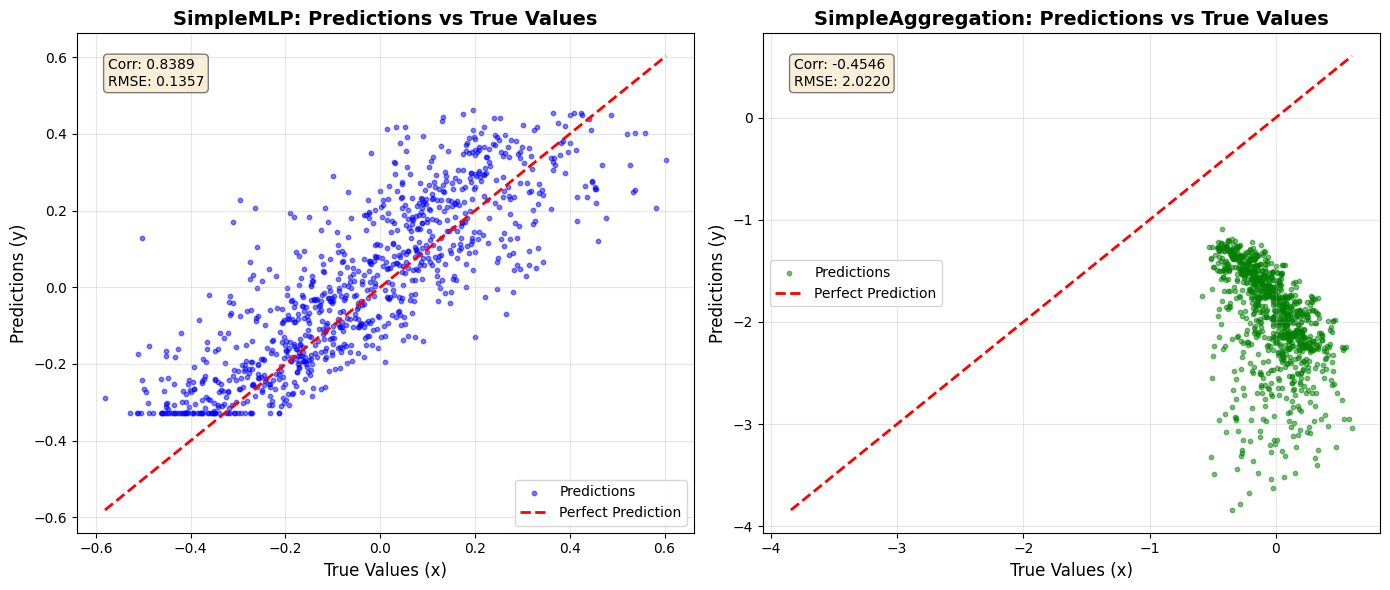


PREDICTION QUALITY ANALYSIS

Data Structure:
  Each graph has 10 nodes
  Total of 940 predictions (one per node across all test graphs)
  True values range: [-0.5810, 0.6031]

SimpleMLP:
  - Points close to diagonal line indicate good predictions
  - Correlation: 0.8389 (higher is better)
  - RMSE: 0.1357 (lower is better)

SimpleAggregation:
  - Negative correlation (-0.4546) suggests model is learning inverse relationship
  - Higher RMSE (2.0220) indicates worse prediction quality
  - May need different learning rate or architecture adjustments


In [6]:
# ==============================================================================
# Debug: Check if true values are identical across models
# ==============================================================================
print("=" * 90)
print("DATA STRUCTURE INSPECTION")
print("=" * 90)

print(f"\nTest set structure:")
print(f"  Number of test graphs: {len(test_graphs)}")
print(f"  Nodes per graph: {test_graphs[0].num_nodes()}")
print(f"  Total test nodes: {len(test_graphs) * test_graphs[0].num_nodes()}")

# Check if labels are the same
labels_mlp = results['SimpleMLP']['labels']
labels_agg = results['SimpleAggregation']['labels']

print(f"\nArray shapes:")
print(f"  SimpleMLP labels: {labels_mlp.shape}")
print(f"  SimpleAggregation labels: {labels_agg.shape}")

print(f"\nAre true values identical?")
print(f"  Arrays equal: {np.array_equal(labels_mlp, labels_agg)}")
print(f"  Max difference: {np.abs(labels_mlp - labels_agg).max()}")

print(f"\nTrue value statistics (should be same for both models):")
print(f"  Min: {labels_mlp.min():.4f}")
print(f"  Max: {labels_mlp.max():.4f}")
print(f"  Mean: {labels_mlp.mean():.4f}")
print(f"  Std: {labels_mlp.std():.4f}")

print(f"\nPrediction statistics:")
for model_name in ['SimpleMLP', 'SimpleAggregation']:
    preds = results[model_name]['predictions']
    print(f"  {model_name}:")
    print(f"    Min: {preds.min():.4f}, Max: {preds.max():.4f}, Mean: {preds.mean():.4f}, Std: {preds.std():.4f}")

print("\n" + "=" * 90)

# ==============================================================================
# Plot Predictions vs True Values
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the SAME true values for both (since they're from the same test set)
true_values = results['SimpleMLP']['labels']  # Same for all models
predictions_mlp = results['SimpleMLP']['predictions']
predictions_agg = results['SimpleAggregation']['predictions']

# Plot for SimpleMLP
ax1 = axes[0]
ax1.scatter(true_values, predictions_mlp, alpha=0.5, s=10, color='blue', label='Predictions')
# Add diagonal line (perfect prediction)
min_val = min(true_values.min(), predictions_mlp.min())
max_val = max(true_values.max(), predictions_mlp.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('True Values (x)', fontsize=12)
ax1.set_ylabel('Predictions (y)', fontsize=12)
ax1.set_title('SimpleMLP: Predictions vs True Values', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add correlation and RMSE text
corr_mlp = results['SimpleMLP']['correlation']
rmse_mlp = np.sqrt(results['SimpleMLP']['test_loss'])
ax1.text(0.05, 0.95, f"Corr: {corr_mlp:.4f}\nRMSE: {rmse_mlp:.4f}", 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot for SimpleAggregation
ax2 = axes[1]
ax2.scatter(true_values, predictions_agg, alpha=0.5, s=10, color='green', label='Predictions')
# Add diagonal line (perfect prediction)
min_val = min(true_values.min(), predictions_agg.min())
max_val = max(true_values.max(), predictions_agg.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_xlabel('True Values (x)', fontsize=12)
ax2.set_ylabel('Predictions (y)', fontsize=12)
ax2.set_title('SimpleAggregation: Predictions vs True Values', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add correlation and RMSE text
corr_agg = results['SimpleAggregation']['correlation']
rmse_agg = np.sqrt(results['SimpleAggregation']['test_loss'])
ax2.text(0.05, 0.95, f"Corr: {corr_agg:.4f}\nRMSE: {rmse_agg:.4f}", 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("PREDICTION QUALITY ANALYSIS")
print("=" * 90)
print(f"\nData Structure:")
print(f"  Each graph has {test_graphs[0].num_nodes()} nodes")
print(f"  Total of {len(true_values)} predictions (one per node across all test graphs)")
print(f"  True values range: [{true_values.min():.4f}, {true_values.max():.4f}]")

print(f"\nSimpleMLP:")
print(f"  - Points close to diagonal line indicate good predictions")
print(f"  - Correlation: {corr_mlp:.4f} (higher is better)")
print(f"  - RMSE: {rmse_mlp:.4f} (lower is better)")

print(f"\nSimpleAggregation:")
print(f"  - Negative correlation ({corr_agg:.4f}) suggests model is learning inverse relationship")
print(f"  - Higher RMSE ({rmse_agg:.4f}) indicates worse prediction quality")
print(f"  - May need different learning rate or architecture adjustments")
print("=" * 90)